In [1]:
# 1. Download the inference results if not already downloaded.

!wget "https://surfdrive.surf.nl/files/index.php/s/G8XWW8On5MWhtCk/download?path=%2FInference&files=inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv" -qO inference_results.csv

# 2. Model checkpoints should be in ../outputs/Cologne-v1/vdn_rnn/

In [1]:
import jax
import jaxmarl

from rollout_data_generator import RolloutDataGenerator
from plotter import RolloutPlotter, plot_action_stats

In [2]:
ENV_NAME = 'Cologne-v1'
ALG = 'vdn_rnn'
env = jaxmarl.make("road_env", map_name=ENV_NAME)
rdg = RolloutDataGenerator(ENV_NAME, ALG, test_num_envs=1_000)
rp = RolloutPlotter(env)

Selected best checkpoint dir and id
Checkpoint dir: 2025-04-29_15-09-09.495665, checkpoint id: 22320


In [ ]:
key = jax.random.PRNGKey(87)
episode_data = rdg.generate_rollout_data(key, verbose=True)

In [4]:
# rdg.save_rollout_data(episode_data)

episode_data = rdg.load_rollout_data()

Rollout data loaded from Cologne-v1/vdn_rnn/2025-04-29_15-09-09.495665/rollout_data_22320.safetensors


## Analysing Multiple Episodes

### Budget overruns

In [5]:
episode_data["budget_constraints_applied"].mean()

Array(0.25966, dtype=float32)

### Action Histograms

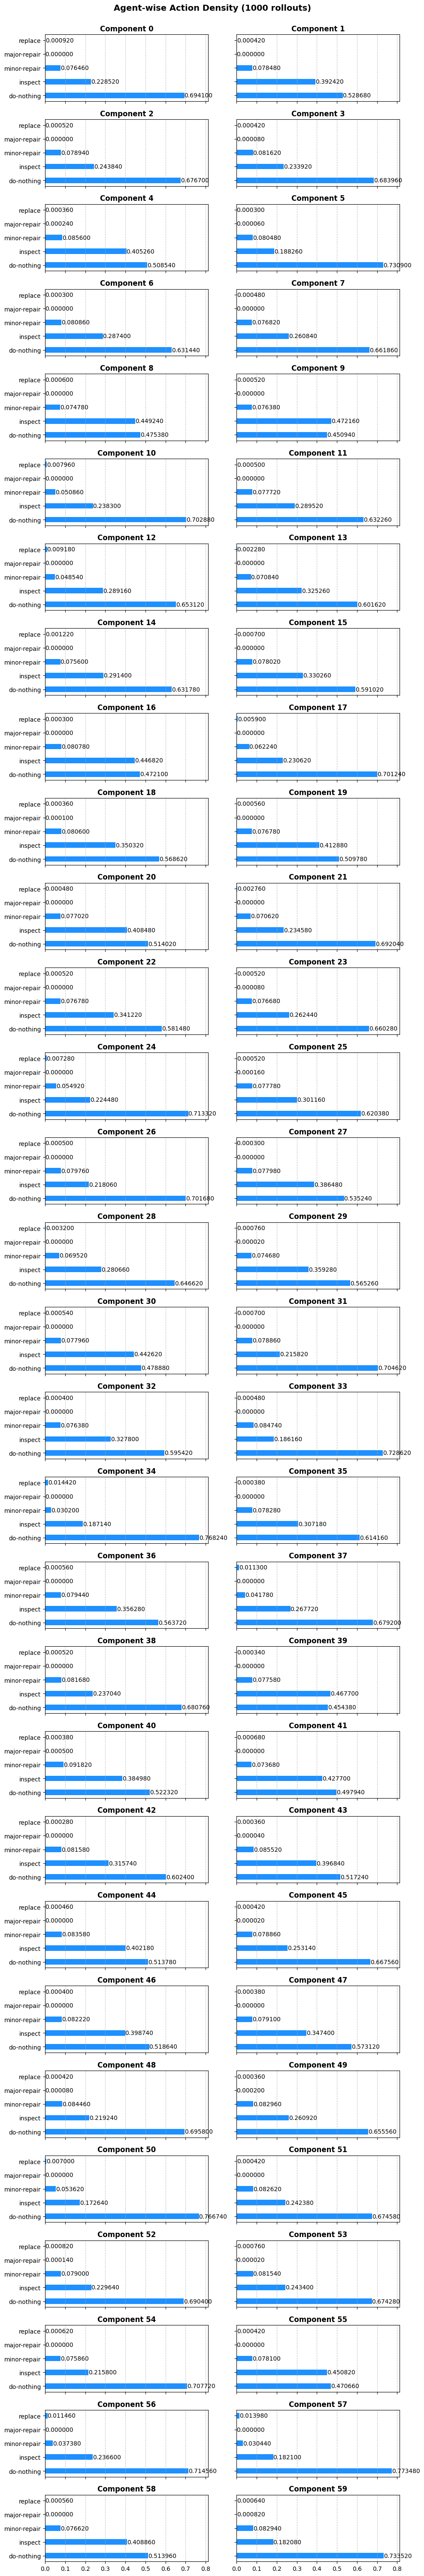

In [7]:
save_fig_kwargs = {
    "fname": f"./rollout_{ENV_NAME}_{ALG}_action_hist.png",
    "dpi": 300,
    "bbox_inches": "tight",
}

save_fig_kwargs = None

plot_action_stats(episode_data['applied_actions'][:1000], save_kwargs=save_fig_kwargs)

## Analysing Single Episodes

In [5]:
# get data for a single episode among all the episode_data
single_episdode_data = rdg.get_single_episode_data(episode_data, episode_idx=435)

In [11]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 8,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  # or 'Times'
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
})

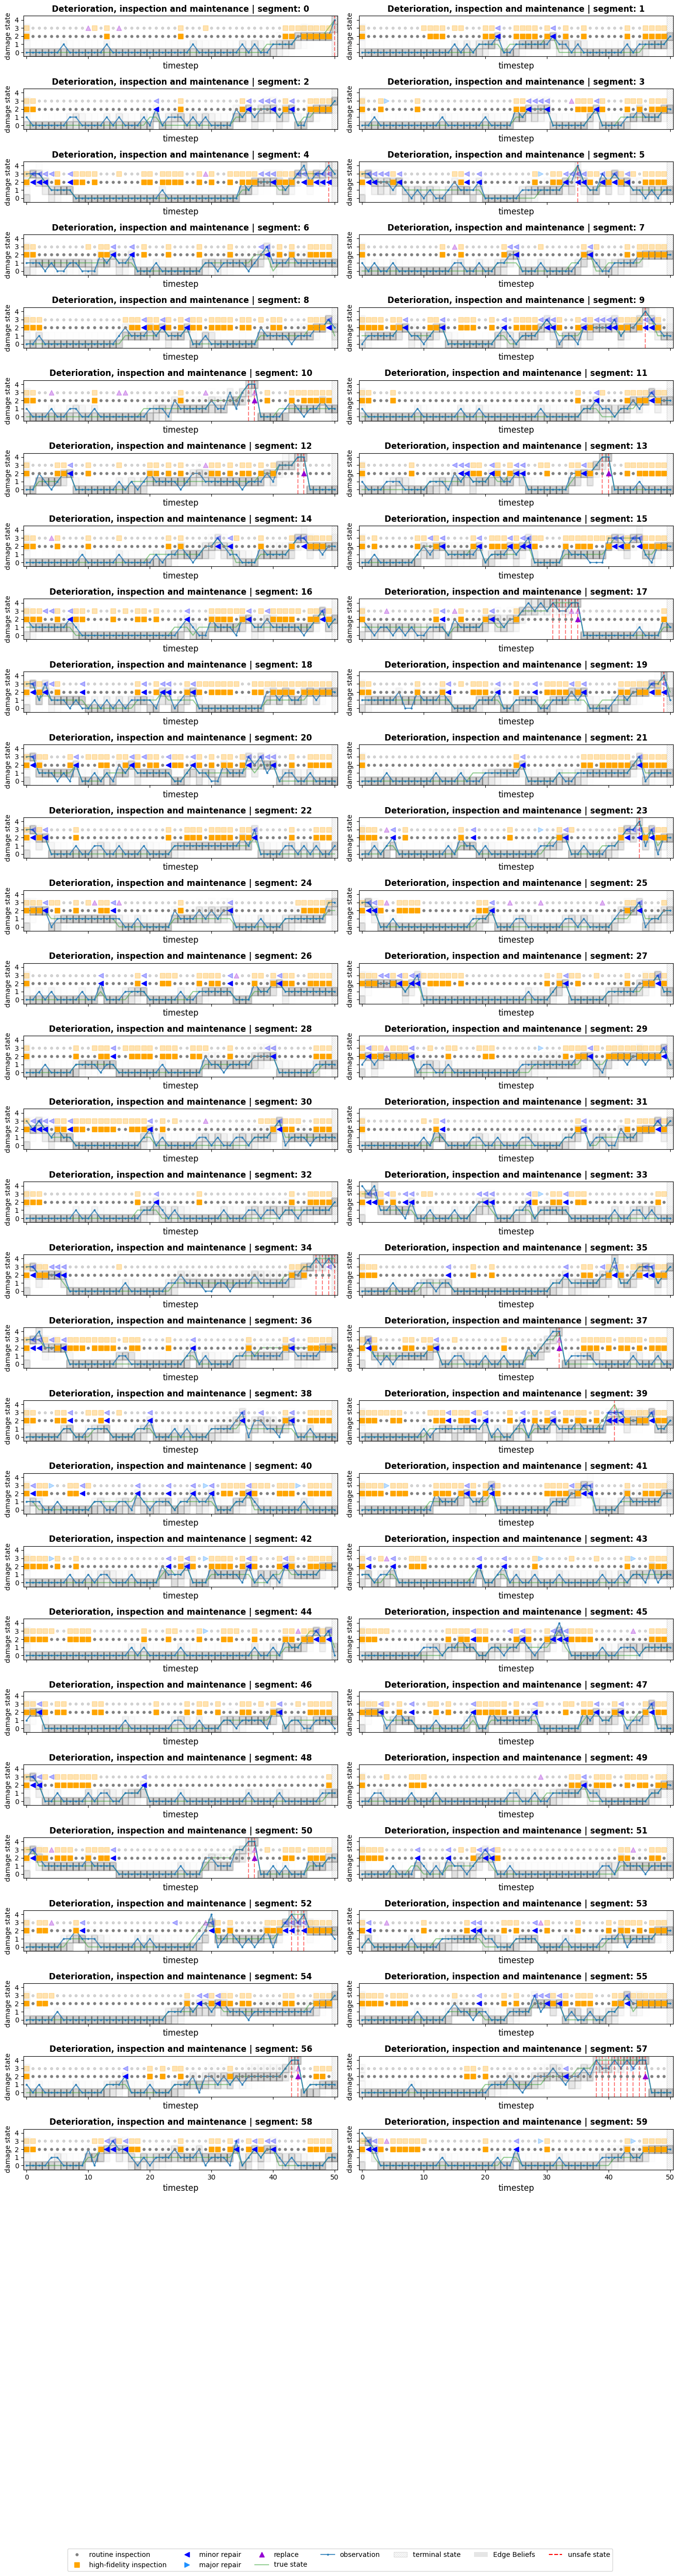

In [6]:
save_fig_kwargs = {
    "fname": "./rollout.pdf",
    "dpi": 300,
    "bbox_inches": "tight",
}
save_fig_kwargs = None

rp._plot_deterioration(single_episdode_data, save_kwargs=save_fig_kwargs)

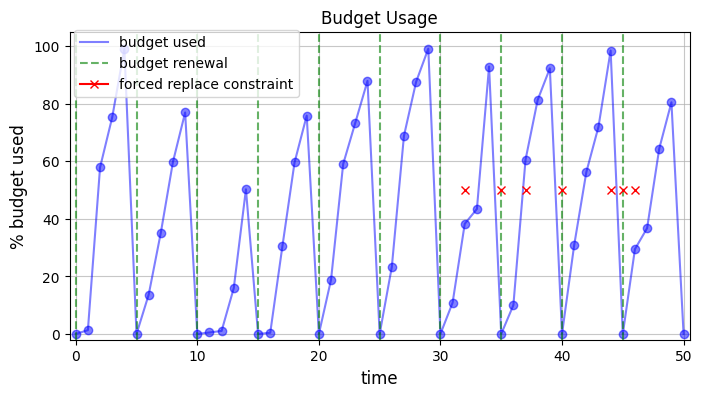

In [7]:
rp._plot_budget(single_episdode_data)

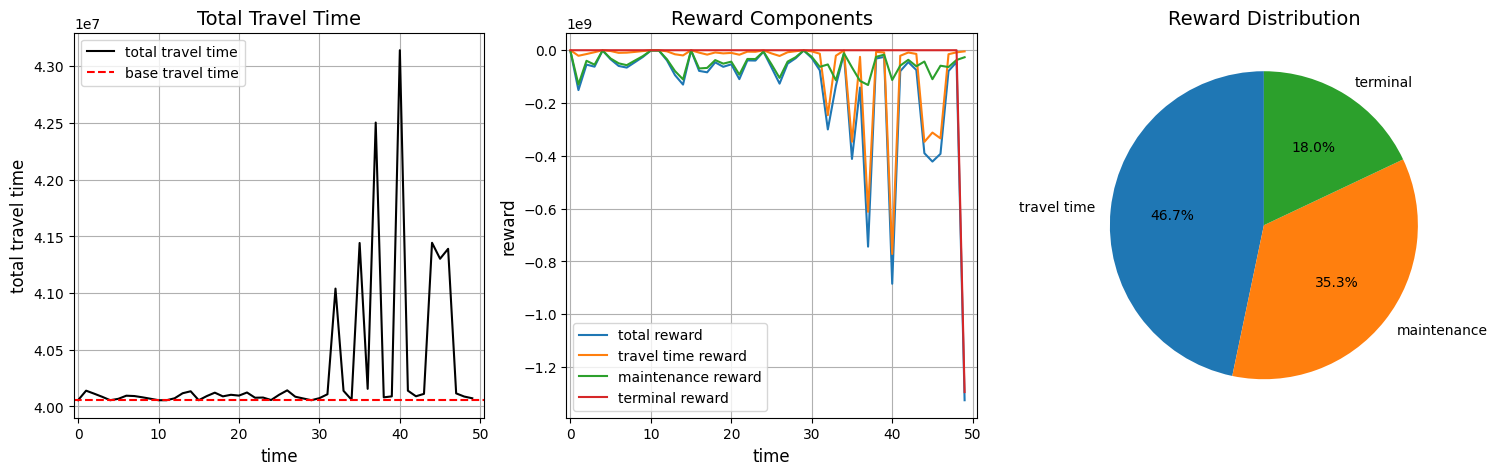

In [7]:
rp._plot_travel_time_and_rewards(single_episdode_data)

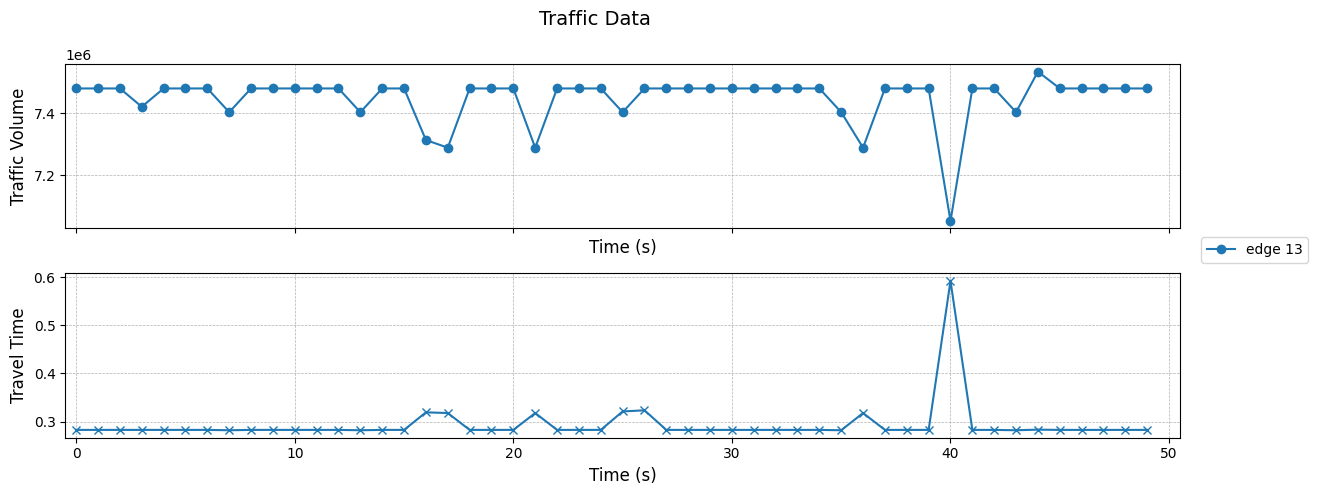

In [6]:
# ToDo: return travel times and traffic volumes in info from jax env
rp._plot_traffic_volume_and_travel_times(single_episdode_data, components_to_show=[13])